# 读取数据

##  振动cwt数据读取

In [9]:
import torch
from torch_geometric.data import Data

# ===== 原始路径 =====
paths = {
    "train": "/home/charles/HZU/Data_processed/my_CIL_V1/KAIST/KAIST_CWT/normalization/train/CWT_pyg/train_graph_with_labelmask.pt",
    "val"  : "/home/charles/HZU/Data_processed/my_CIL_V1/KAIST/KAIST_CWT/normalization/val/CWT_pyg/graph.pt",
    "test" : "/home/charles/HZU/Data_processed/my_CIL_V1/KAIST/KAIST_CWT/normalization/test/CWT_pyg/graph.pt",
}

def to_pyg_data(path):
    data = torch.load(path)

    pyg_data = Data(
        x=data.x,
        edge_index=data.edge_index,
        y=data.y if hasattr(data, "y") else None
    )

    # 保留所有 mask
    for attr in dir(data):
        if "mask" in attr:
            m = getattr(data, attr)
            if torch.is_tensor(m):
                setattr(pyg_data, attr, m)

    return pyg_data


# ===== 存到变量 =====
vibration_cwt_train = to_pyg_data(paths["train"])
vibration_cwt_val   = to_pyg_data(paths["val"])
vibration_cwt_test  = to_pyg_data(paths["test"])


# ===== 快速 sanity check =====
print("Train :", vibration_cwt_train)
print("Val   :", vibration_cwt_val)
print("Test  :", vibration_cwt_test)


Train : Data(x=[1639, 124], edge_index=[2, 32780], y=[1639])
Val   : Data(x=[272, 124], edge_index=[2, 5440], y=[272])
Test  : Data(x=[819, 124], edge_index=[2, 16380], y=[819])


/tmp/ipykernel_852687/883891547.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(path)


## 读取电流和温度数据

In [10]:
import torch
from torch_geometric.data import Data

# ===== 原始路径 =====
paths_ct = {
    "train": "/home/charles/HZU/Data_processed/HSML/KAIST/current&temp_raw_wl_5000/train/pyg/train_graph_with_labelmask.pt",
    "val"  : "/home/charles/HZU/Data_processed/HSML/KAIST/current&temp_raw_wl_5000/val/pyg/graph.pt",
    "test" : "/home/charles/HZU/Data_processed/HSML/KAIST/current&temp_raw_wl_5000/test/pyg/graph.pt",
}

def to_pyg_data(path):
    data = torch.load(path)

    pyg_data = Data(
        x=data.x,
        edge_index=data.edge_index,
        y=data.y if hasattr(data, "y") else None
    )

    # 保留所有 mask（train_withlabel_mask / train_nolabel_mask 等）
    for attr in dir(data):
        if "mask" in attr:
            m = getattr(data, attr)
            if torch.is_tensor(m):
                setattr(pyg_data, attr, m)

    return pyg_data


# ===== 存为变量 =====
current_temp_train = to_pyg_data(paths_ct["train"])
current_temp_val   = to_pyg_data(paths_ct["val"])
current_temp_test  = to_pyg_data(paths_ct["test"])


# ===== sanity check =====
print("Train :", current_temp_train)
print("Val   :", current_temp_val)
print("Test  :", current_temp_test)

import torch

def drop_last_nan_columns(data, drop_last_k=3, drop_second_last=True):
    """
    删除 x 中倒数第 2、3 列（或更一般地，删除倒数 k 列）
    """
    x = data.x

    # 原始维度
    F = x.size(1)

    # 这里明确删除：倒数第 3 和第 2 列
    # 等价于保留前 F-3 列
    keep_dim = F - drop_last_k
    assert keep_dim > 0, "Feature dimension too small to drop columns"

    x_new = x[:, :keep_dim]

    # 强制检查是否还存在 NaN / Inf
    assert not torch.isnan(x_new).any(), "NaN still exists after dropping columns"
    assert not torch.isinf(x_new).any(), "Inf exists after dropping columns"

    data.x = x_new
    return data


# =========================================================
# 对 current & temp 的三个 split 同步处理
# =========================================================
current_temp_train = drop_last_nan_columns(current_temp_train)
current_temp_val   = drop_last_nan_columns(current_temp_val)
current_temp_test  = drop_last_nan_columns(current_temp_test)

# =========================================================
# sanity check
# =========================================================
print("Train x shape:", current_temp_train.x.shape)
print("Val   x shape:", current_temp_val.x.shape)
print("Test  x shape:", current_temp_test.x.shape)

print("NaN check (train):", torch.isnan(current_temp_train.x).any().item())
print("NaN check (val)  :", torch.isnan(current_temp_val.x).any().item())
print("NaN check (test) :", torch.isnan(current_temp_test.x).any().item())


Train : Data(x=[45000, 5], edge_index=[2, 900000], y=[45000])
Val   : Data(x=[7500, 5], edge_index=[2, 150000], y=[7500])
Test  : Data(x=[22500, 5], edge_index=[2, 450000], y=[22500])
Train x shape: torch.Size([45000, 2])
Val   x shape: torch.Size([7500, 2])
Test  x shape: torch.Size([22500, 2])
NaN check (train): False
NaN check (val)  : False
NaN check (test) : False


/tmp/ipykernel_852687/3625691366.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(path)


### 利用滑窗对齐图规模

In [11]:
import torch
from torch_geometric.data import Data

def window_align_graph(raw_graph, target_num_nodes):
    """
    raw_graph: PyG Data
        x: [N_raw, F]
        y: [N_raw]
    target_num_nodes: int (振动图该 split 的节点数)
    """
    x_raw = raw_graph.x
    y_raw = raw_graph.y

    N_raw = x_raw.size(0)
    F = x_raw.size(1)

    win_size = N_raw // target_num_nodes
    assert win_size > 0, f"Invalid window size: {win_size}"

    x_win, y_win = [], []

    for i in range(target_num_nodes):
        start = i * win_size
        end = (i + 1) * win_size if i < target_num_nodes - 1 else N_raw

        x_slice = x_raw[start:end]    # [w, F]
        y_slice = y_raw[start:end]    # [w]

        # ---- 特征：窗口均值 ----
        x_feat = x_slice.mean(dim=0)

        # ---- 标签：多数投票 ----
        labels, counts = torch.unique(y_slice, return_counts=True)
        y_label = labels[counts.argmax()]

        x_win.append(x_feat)
        y_win.append(y_label)

    x_win = torch.stack(x_win)   # [N_target, F]
    y_win = torch.stack(y_win)   # [N_target]

    return Data(x=x_win, y=y_win)


# =========================================================
# 对三个 split 分别对齐（窗口大小各不相同）
# =========================================================

# ---- 振动图节点数（目标）----
N_train = vibration_cwt_train.x.size(0)
N_val   = vibration_cwt_val.x.size(0)
N_test  = vibration_cwt_test.x.size(0)

# ---- 电流&温度对齐 ----
ct_train_aligned = window_align_graph(current_temp_train, N_train)
ct_val_aligned   = window_align_graph(current_temp_val,   N_val)
ct_test_aligned  = window_align_graph(current_temp_test,  N_test)

# ---- sanity check ----
print("Train aligned:", ct_train_aligned.x.shape, ct_train_aligned.y.shape)
print("Val aligned  :", ct_val_aligned.x.shape,   ct_val_aligned.y.shape)
print("Test aligned :", ct_test_aligned.x.shape,  ct_test_aligned.y.shape)


Train aligned: torch.Size([1639, 2]) torch.Size([1639])
Val aligned  : torch.Size([272, 2]) torch.Size([272])
Test aligned : torch.Size([819, 2]) torch.Size([819])


### 重建滑窗后的电流温度数据图

In [12]:
import torch
from torch_geometric.data import Data

def build_temporal_graph(data, k=3, add_self_loop=True):
    """
    data: PyG Data
        data.x: [N, F]
    k: 相邻的节点数（左右各 k 个）
    add_self_loop: 是否加入自环
    """
    N = data.x.size(0)
    edge_list = []

    for i in range(N):
        # ----- 相邻 k 个节点 -----
        for j in range(max(0, i - k), min(N, i + k + 1)):
            if i != j:
                edge_list.append([i, j])

        # ----- 自环 -----
        if add_self_loop:
            edge_list.append([i, i])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    # 构造新的 Data，保留 x / y
    new_data = Data(
        x=data.x,
        y=data.y,
        edge_index=edge_index
    )

    return new_data


# =========================================================
# 对三个 split 分别重构图结构
# =========================================================
k_neighbors = 3   # ⭐ 可调：3 / 5 / 7 都是常见选择

ct_train_graph = build_temporal_graph(ct_train_aligned, k=k_neighbors)
ct_val_graph   = build_temporal_graph(ct_val_aligned,   k=k_neighbors)
ct_test_graph  = build_temporal_graph(ct_test_aligned,  k=k_neighbors)

# =========================================================
# sanity check
# =========================================================
print("Train:", ct_train_graph)
print("Val  :", ct_val_graph)
print("Test :", ct_test_graph)

print("Train edge_index shape:", ct_train_graph.edge_index.shape)


Train: Data(x=[1639, 2], edge_index=[2, 11461], y=[1639])
Val  : Data(x=[272, 2], edge_index=[2, 1892], y=[272])
Test : Data(x=[819, 2], edge_index=[2, 5721], y=[819])
Train edge_index shape: torch.Size([2, 11461])


# GCL表征学习

## 模型初始化

In [13]:
# =========================================================
# 0️⃣ 基础导入
# =========================================================
import sys
import torch

# =========================================================
# 1️⃣ 添加 model.py 所在路径
# =========================================================
MODEL_PATH = (
    "/home/charles/HZU/Industrial_Software_Testing/"
    "Industrial_Software_Testing/High_similar_ML/"
    "baseline/MMHGAT/src"
)
sys.path.append(MODEL_PATH)

# =========================================================
# 2️⃣ 导入你定义的模型
# =========================================================
from model import GraphContrastiveLearner

# =========================================================
# 3️⃣ 设备
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# 4️⃣ 根据图数据自动推断维度（以振动 CWT train 图为例）
# =========================================================
in_dim = vibration_cwt_train.x.size(1)     # 节点特征维度
hidden_dim = 256
out_dim = 128
proj_dim = 128
tau = 0.5

print(f"in_dim={in_dim}, hidden_dim={hidden_dim}, out_dim={out_dim}, proj_dim={proj_dim}")

# =========================================================
# 5️⃣ 初始化 GCL 模型
# =========================================================
gcl_model = GraphContrastiveLearner(
    in_dim=in_dim,
    hidden_dim=hidden_dim,
    out_dim=out_dim,
    proj_dim=proj_dim,
    tau=tau
).to(device)

print("\n✅ GraphContrastiveLearner initialized")
print(gcl_model)

# =========================================================
# 6️⃣ Optimizer（仅用于表征学习阶段）
# =========================================================
optimizer = torch.optim.Adam(
    gcl_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

print("✅ Optimizer ready")


Using device: cuda
in_dim=124, hidden_dim=256, out_dim=128, proj_dim=128

✅ GraphContrastiveLearner initialized
GraphContrastiveLearner(
  (encoder): GCNEncoder(
    (conv1): SAGEConv(124, 256, aggr=mean)
    (conv2): SAGEConv(256, 128, aggr=mean)
  )
  (projector): MLPHead(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (act): GELU(approximate='none')
    (fc2): Linear(in_features=128, out_features=128, bias=True)
  )
)
✅ Optimizer ready


## GCL训练

In [14]:
# =========================================================
# 0️⃣ 基础准备
# =========================================================
import sys
import torch
import copy
from tqdm import trange
from torch_geometric.data import Data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# 1️⃣ ct 滑窗对齐（按 train split）
# =========================================================
N_train = vibration_cwt_train.x.size(0)

ct_train_aligned = window_align_graph(
    current_temp_train,
    target_num_nodes=N_train
)

# =========================================================
# 2️⃣ ct 图结构重构：时间相邻 k 节点 + 自环
# =========================================================
def build_temporal_graph(data, k=3, add_self_loop=True):
    N = data.x.size(0)
    edge_list = []

    for i in range(N):
        for j in range(max(0, i - k), min(N, i + k + 1)):
            if i != j:
                edge_list.append([i, j])
        if add_self_loop:
            edge_list.append([i, i])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    return Data(
        x=data.x,
        y=data.y,
        edge_index=edge_index
    )

ct_train_graph = build_temporal_graph(ct_train_aligned, k=3).to(device)
vibration_cwt_train = vibration_cwt_train.to(device)

print("Vibration graph:", vibration_cwt_train)
print("CT graph       :", ct_train_graph)

# =========================================================
# 3️⃣ 安全版图增强（防 None edge_index）
# =========================================================
def augment_graph(data, feature_drop=0.1, edge_drop=0.1, noise_std=0.01):
    assert hasattr(data, "edge_index") and data.edge_index is not None, \
        "augment_graph requires data.edge_index!"

    aug = copy.deepcopy(data)

    # ---- 特征增强 ----
    x = aug.x.clone()
    mask = torch.rand_like(x) > feature_drop
    x = x * mask + noise_std * torch.randn_like(x)
    aug.x = x

    # ---- 边增强 ----
    edge_index = aug.edge_index.clone()
    keep_mask = torch.rand(edge_index.size(1), device=edge_index.device) > edge_drop
    aug.edge_index = edge_index[:, keep_mask]

    return aug

# =========================================================
# 4️⃣ 初始化两个 GCL 模型（模态独立）
# =========================================================
gcl_vib = GraphContrastiveLearner(
    in_dim=vibration_cwt_train.x.size(1),
    hidden_dim=256,
    out_dim=128,
    proj_dim=128,
    tau=0.5
).to(device)

gcl_ct = GraphContrastiveLearner(
    in_dim=ct_train_graph.x.size(1),
    hidden_dim=128,
    out_dim=128,
    proj_dim=128,
    tau=0.5
).to(device)

opt_vib = torch.optim.Adam(gcl_vib.parameters(), lr=1e-3, weight_decay=1e-5)
opt_ct  = torch.optim.Adam(gcl_ct.parameters(),  lr=1e-3, weight_decay=1e-5)

print("✅ Two independent GCL models initialized")

# =========================================================
# 5️⃣ 单模态 GCL 训练函数
# =========================================================
def train_gcl_one_epoch(model, optimizer, data):
    model.train()

    aug1 = augment_graph(data)
    aug2 = augment_graph(data)

    x1, e1 = aug1.x, aug1.edge_index
    x2, e2 = aug2.x, aug2.edge_index

    loss = model.compute_loss(x1, e1, x2, e2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

# =========================================================
# 6️⃣ GCL 训练主循环（两模态分开）
# =========================================================
num_epochs = 200
log_interval = 10

print("\n🚀 Start GCL pretraining (separate modalities)\n")

for epoch in trange(1, num_epochs + 1):

    loss_vib = train_gcl_one_epoch(
        gcl_vib, opt_vib, vibration_cwt_train
    )

    loss_ct = train_gcl_one_epoch(
        gcl_ct, opt_ct, ct_train_graph
    )

    if epoch == 1 or epoch % log_interval == 0:
        print(
            f"[Epoch {epoch:03d}] "
            f"Vibration GCL Loss = {loss_vib:.4f} | "
            f"Current&Temp GCL Loss = {loss_ct:.4f}"
        )

print("\n✅ GCL pretraining finished")


Using device: cuda
Vibration graph: Data(x=[1639, 124], edge_index=[2, 32780], y=[1639])
CT graph       : Data(x=[1639, 2], edge_index=[2, 11461], y=[1639])
✅ Two independent GCL models initialized

🚀 Start GCL pretraining (separate modalities)



  2%|▎         | 5/200 [00:00<00:08, 22.09it/s]

[Epoch 001] Vibration GCL Loss = 33.0875 | Current&Temp GCL Loss = 33.4795


  8%|▊         | 17/200 [00:00<00:05, 32.88it/s]

[Epoch 010] Vibration GCL Loss = 31.7375 | Current&Temp GCL Loss = 33.3849


...

[Epoch 180] Vibration GCL Loss = 30.3098 | Current&Temp GCL Loss = 32.7429


 98%|█████████▊| 195/200 [00:05<00:00, 37.91it/s]

[Epoch 190] Vibration GCL Loss = 30.2105 | Current&Temp GCL Loss = 32.7537


100%|██████████| 200/200 [00:05<00:00, 36.54it/s]

[Epoch 200] Vibration GCL Loss = 30.1419 | Current&Temp GCL Loss = 32.6168

✅ GCL pretraining finished


## 双图t-SNE可视化

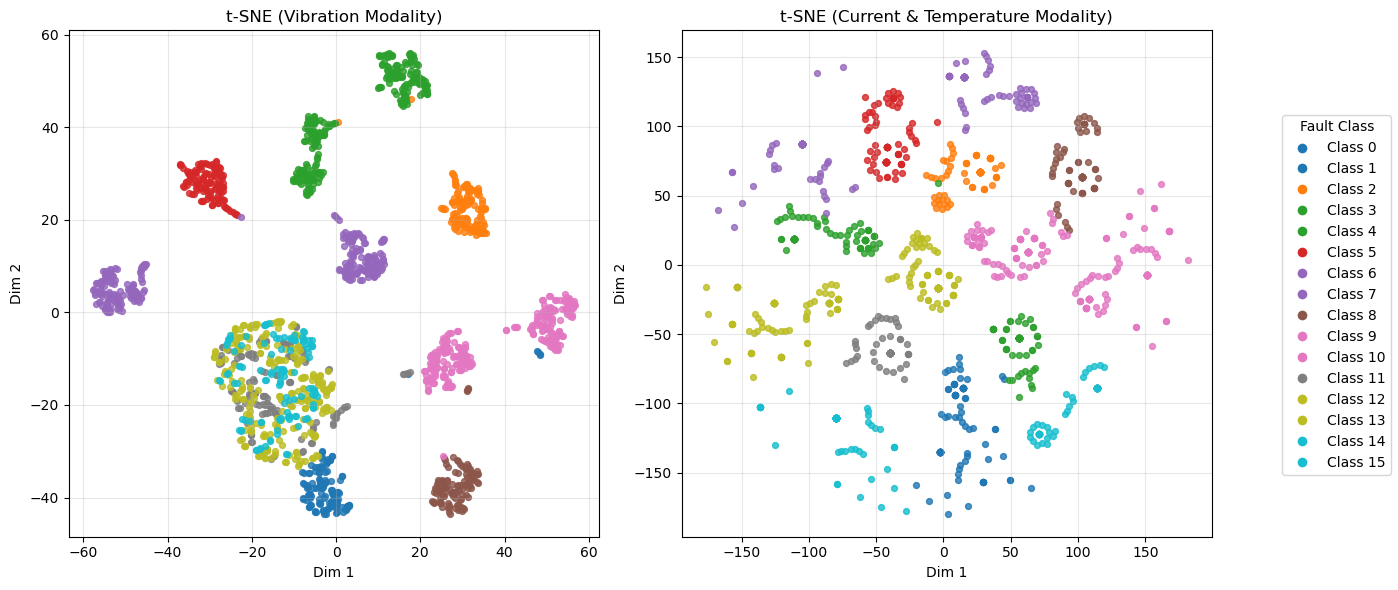

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# 基础数据
# =========================
z_vib = z_vib_2d      # [N, 2]
z_ct  = z_ct_2d       # [N, 2]
y_vib = y_vib         # [N]
y_ct  = y_ct          # [N]

num_classes = int(max(y_vib.max(), y_ct.max()) + 1)

# =========================
# 固定离散颜色表（全局一致）
# =========================
cmap = plt.get_cmap("tab10", num_classes)
colors = [cmap(i) for i in range(num_classes)]

# =========================
# 画图
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for cls in range(num_classes):
    idx_v = (y_vib == cls)
    idx_c = (y_ct  == cls)

    axes[0].scatter(
        z_vib[idx_v, 0], z_vib[idx_v, 1],
        color=colors[cls], s=18, alpha=0.8
    )

    axes[1].scatter(
        z_ct[idx_c, 0], z_ct[idx_c, 1],
        color=colors[cls], s=18, alpha=0.8
    )

axes[0].set_title("t-SNE (Vibration Modality)")
axes[1].set_title("t-SNE (Current & Temperature Modality)")

for ax in axes:
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.grid(alpha=0.3)

# =========================
# 离散 legend（而不是 colorbar）
# =========================
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=f"Class {i}",
        markerfacecolor=colors[i],
        markersize=8
    )
    for i in range(num_classes)
]

fig.legend(
    handles=legend_elements,
    loc="center right",
    title="Fault Class"
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()
